### Flood Masks EDA: recurring vs unusual floods

**Question:** the flood archive splits every flooded pixel into *recurring* and *unusual*. What does that split mean, does it behave as expected, and can we reproduce it?

**Where the rule comes from:** the NASA user guide in `literature/MCDWD_VCDWD_UserGuide_RevF.pdf`, **section 3.5.2 "Recurring flood" (printed pages 21–22)**. Step 6 of the processing overview on page 12 describes how the mask is applied to each day. In short: a pixel is *recurring flood* for a calendar month if it was confidently flooded in at least 7 of the 22 years 2003–2024 in the three months around that month; every other flood is *unusual*. Section 4 below lists the rule in full.

**Approach**
1. Load the whole archive: for every pixel, year and month, the number of days flagged as flooded, with its label.
2. Time series of recurring and unusual flooding, per year and per month, with months that have data gaps flagged.
3. Test whether the label belongs to the flood event or to the place.
4. Recalculate the labels ourselves with NASA's rule and compare.
5. Variant: the same rule against a pre-2020 reference period.
6. Where the post-2020 unusual flooding is.

**Read before interpreting**
* The tiles cover 0–10°N and 20–40°E, so this includes flooding outside South Sudan (e.g. Sudan, Uganda, Ethiopia).
* 2000–2002 are Terra-only and undercounted; everything below uses 2003 onwards.
* Loading the archive takes a few minutes.

In [1]:
import os
from pathlib import Path

# Work from the repo root so the raw_data paths resolve the same way as in the other notebooks
REPO = Path.cwd().resolve()
while not (REPO / "raw_data").is_dir():
    if REPO == REPO.parent:
        raise FileNotFoundError("Repo root (folder containing raw_data/) not found")
    REPO = REPO.parent
os.chdir(REPO)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import geopandas as gpd
from scipy import ndimage
from scipy.stats import beta

FLOOD = REPO / "raw_data" / "flood_masks"
TILES = ["h20v08", "h21v08"]
RES = 10 / 4800        # pixel size in degrees (4800 pixels per 10-degree tile)
FIRST, LAST = 2003, 2025
OUT = REPO / "EDA" / "outputs"
FIG = OUT / "figures"
FIG.mkdir(parents=True, exist_ok=True)

# chart styling, shared with the other EDA figures (blue/orange pair validated for colour-blind readers)
INK, INK2, MUTED, GRID, AXIS, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
BLUE, ORANGE = "#2a78d6", "#eb6834"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK2, "axes.titlecolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.grid": True, "axes.axisbelow": True,
    "grid.color": GRID, "grid.linewidth": 0.6, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 11, "axes.titleweight": "bold", "legend.frameon": False,
    "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "DejaVu Sans"],
})

#### 1. Load the archive
Each record is a (day, pixel) where flooding was detected. A pixel gets an ID from its position on the tile grid (row × 100,000 + column). For every pixel, year and month we keep the **number of flooded days** and the label. We also keep which days have any record at all, to find data gaps.

In [2]:
parts, seen = [], []
for year in range(FIRST - 1, LAST + 1):          # 2002 is loaded only for the December window of 2003
    for label in ["recurring", "unusual"]:
        for tile in TILES:
            df = pd.read_parquet(FLOOD / f"compact_{label}" / f"flood_events_{tile}_{year}.parquet",
                                 columns=["date", "lat", "lon"])
            date = pd.to_datetime(df["date"].astype(str))
            seen.append(date.unique())
            pixel = (np.floor(df["lat"].to_numpy(np.float64) / RES).astype(np.int64) * 100_000
                     + np.floor(df["lon"].to_numpy(np.float64) / RES).astype(np.int64))
            t = pd.DataFrame({"pixel": pixel, "date": date}).drop_duplicates()
            t = t.groupby([t["pixel"], t["date"].dt.month.rename("month")]).size().rename("days").reset_index()
            parts.append(t.assign(year=np.int16(year), label=label))
    print(year, end=" ")

days = pd.concat(parts, ignore_index=True)
days = days.astype({"month": "int8", "days": "int16", "label": "category"})
seen = pd.DatetimeIndex(np.concatenate(seen)).unique()
obs = days[days["year"] >= FIRST]                  # the analysis period
print(f"\n{len(obs):,} (pixel, year, month, label) rows for {FIRST}–{LAST}")

2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025 
12,882,383 (pixel, year, month, label) rows for 2003–2025


**Months with data gaps.** Days without any record are outages (see `EDA/hydro_flood_eda.ipynb`). Months with 3 or more of them undercount flooding, so they're flagged in the time series below.

In [3]:
missing = pd.date_range(f"{FIRST}-01-01", f"{LAST}-12-31").difference(seen)
gaps = pd.Series(1, index=missing).groupby([missing.year, missing.month]).sum()
gaps.index.names = ["year", "month"]
flagged = gaps[gaps >= 3]
display(flagged.rename("days without records").to_frame())

days without records
year month                      
2006 4                        18
     5                        19
2007 11                       12

#### 2. Time series: does recurring flooding grow?

label,recurring,unusual
year,,
2003,35797,133149
2004,29767,85879
2005,32506,147985
2006,36752,155561
2007,43204,247475
2008,42817,198473
2009,33151,184566
2010,38121,173747
2011,33765,128735


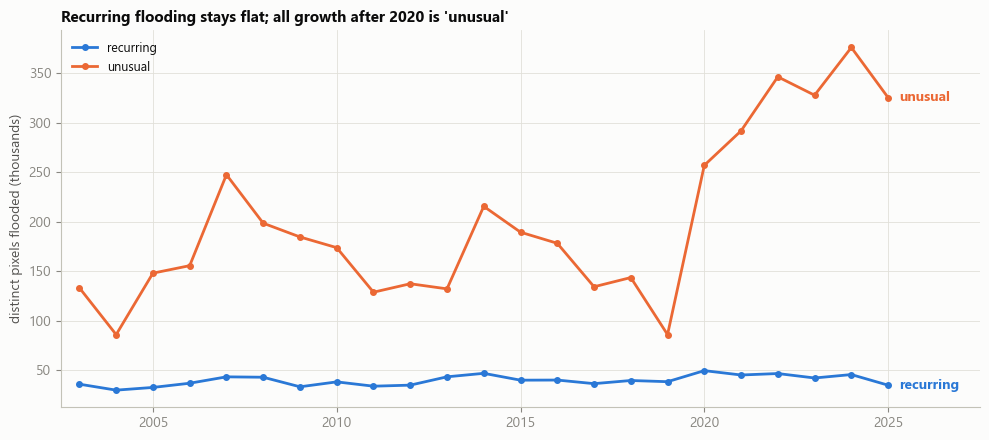

In [4]:
per_year = obs.groupby(["year", "label"], observed=True)["pixel"].nunique().unstack()
display(per_year)

fig, ax = plt.subplots(figsize=(10, 4.5))
for label, col in [("recurring", BLUE), ("unusual", ORANGE)]:
    s = per_year[label]
    ax.plot(s.index, s.to_numpy() / 1000, color=col, lw=2, marker="o", ms=4, label=label)
    ax.annotate(label, (s.index[-1], s.iloc[-1] / 1000), xytext=(8, 0), textcoords="offset points",
                va="center", color=col, fontsize=10, fontweight="bold")
ax.set_xlim(FIRST - 0.5, LAST + 2.5)
ax.set_ylabel("distinct pixels flooded (thousands)")
ax.set_title("Recurring flooding stays flat; all growth after 2020 is 'unusual'", loc="left")
ax.legend(loc="upper left", fontsize=9)
fig.tight_layout()
fig.savefig(FIG / "flood_types_per_year.png", dpi=200)
plt.show()

The same per month. Grey bars mark the months with data gaps; their dips are missing data, not dry spells.

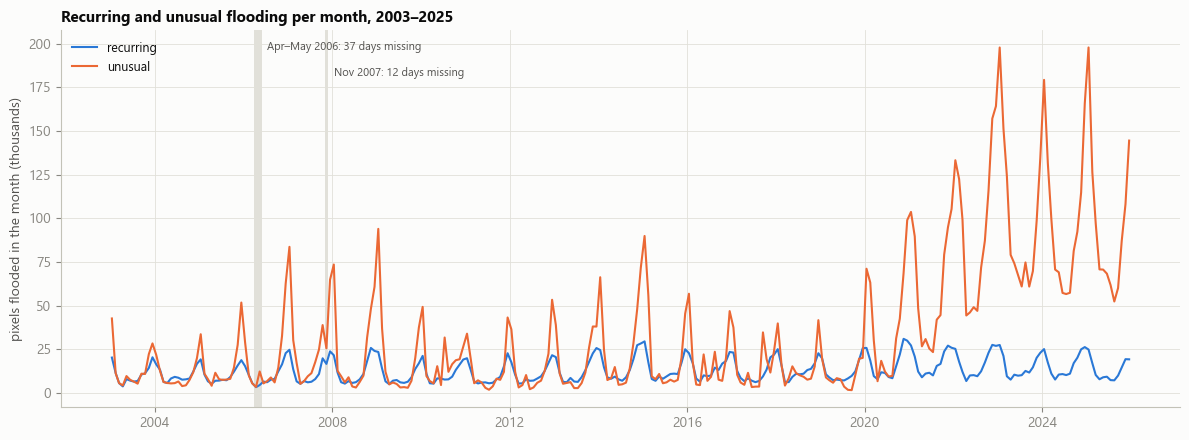

In [5]:
monthly = obs.groupby(["year", "month", "label"], observed=True).size().unstack()
monthly.index = pd.to_datetime([f"{y}-{m:02d}-15" for y, m in monthly.index])

fig, ax = plt.subplots(figsize=(12, 4.5))
for (y, m), n in flagged.items():
    ax.axvspan(pd.Timestamp(y, m, 1), pd.Timestamp(y, m, 1) + pd.offsets.MonthEnd(1), color=GRID, lw=0)
for label, col in [("recurring", BLUE), ("unusual", ORANGE)]:
    ax.plot(monthly.index, monthly[label] / 1000, color=col, lw=1.5, label=label)
runs = []                                         # merge consecutive flagged months into one label
for (y, m), n in flagged.items():
    month = pd.Period(year=y, month=m, freq="M")
    if runs and month == runs[-1][1] + 1:
        runs[-1] = (runs[-1][0], month, runs[-1][2] + n)
    else:
        runs.append((month, month, n))
for i, (first, last, n) in enumerate(runs):
    when = first.strftime("%b %Y") if first == last else f"{first.strftime('%b')}–{last.strftime('%b %Y')}"
    ax.annotate(f"{when}: {n} days missing", (last.end_time, ax.get_ylim()[1] * (0.97 - 0.07 * i)),
                xytext=(4, 0), textcoords="offset points", ha="left", va="top", fontsize=8, color=INK2)
ax.set_ylabel("pixels flooded in the month (thousands)")
ax.set_title("Recurring and unusual flooding per month, 2003–2025", loc="left")
ax.legend(loc="upper left", fontsize=9)
fig.tight_layout()
fig.savefig(FIG / "flood_types_per_month.png", dpi=200)
plt.show()

Recurring flooding follows the seasons but has no trend: its peaks are as high in 2005 as in 2024. Unusual flooding jumps in 2020 and stays high. The next sections explain why the two behave so differently.

#### 3. Is the label a property of the flood, or of the place?
If the label described each flood event, the same pixel in the same calendar month could be recurring in one year and unusual in another.

In [6]:
n_labels = obs.groupby(["pixel", "month"], observed=True)["label"].nunique()
print(f"(pixel, calendar month) combinations: {len(n_labels):,}")
print(f"  with BOTH labels across the years: {(n_labels > 1).sum():,} ({(n_labels > 1).mean():.3%})")

(pixel, calendar month) combinations: 5,873,355
  with BOTH labels across the years: 971 (0.017%)


**The label belongs to the place, not to the flood**, which matches the guide: NASA built one fixed *recurring flood mask* per calendar month and labels every detected flood inside it as recurring. So "recurring" means *this place normally floods in this month*, and "unusual" means *it doesn't*. It says nothing about whether a given year's flood is unusually large.

It follows that **recurring flooding cannot grow**: it is limited to the fixed mask, so any extra flooded area, however much, shows up as unusual.

#### 4. Recalculating the labels with NASA's rule
The rule from section 3.5.2, step by step:

1. Use the daily 2-day composite flood maps, 2003–2024.
2. For each calendar month, use a 3-month window centred on it (January = December–January–February).
3. For each pixel, year and window, count **K** = flooded days and **N** = valid (cloud-free) days. Skip the window if N < 10.
4. Compute the 90% Clopper–Pearson lower bound on the flood fraction K/N, and multiply by 90 days: **d_cp**, the number of days the pixel was *confidently* flooded.
5. The year is a **flood year** if d_cp ≥ **D = 3**.
6. The pixel is **recurring** for that month if it has at least **Y = 7** flood years in the **W = 22** years.
7. Apply a 3×3 majority filter that only fills gaps (a pixel becomes recurring if at least 5 of the 9 pixels around it are).

**What we can't reproduce exactly:**
* **N, the valid days, is not in our extract** (the "insufficient data" information was dropped). Without N we can't compute the bound per pixel. But the bound only depends on K and N, so we can compute the two extremes: if all 90 days were clear (N = 90), a flood year needs at least 6 flooded days (**strict**); if only 10 were (the minimum NASA accepts), it needs at least 2 (**lenient**). NASA's real threshold lies somewhere in between for every pixel.
* Our archive is built from **3-day** composites, NASA used **2-day** ones; a 3-day composite flags slightly more days.
* For January's window we take December of the *previous* year, and for December's, January of the *next* year; the guide doesn't spell this out.

In [7]:
def min_flood_days(n_valid, d=3, alpha=0.10, window=90):
    """Smallest K whose Clopper-Pearson lower bound, scaled to the window, reaches D days."""
    return next(k for k in range(1, n_valid + 1) if window * beta.ppf(alpha, k, n_valid - k + 1) >= d)

K_STRICT, K_LENIENT = min_flood_days(90), min_flood_days(10)
print(f"flood year needs at least {K_STRICT} flooded days if N = 90 (strict), {K_LENIENT} if N = 10 (lenient)")

# K: flooded days per pixel, year and 3-month window centred on each month
d = days.groupby(["pixel", "year", "month"], observed=True)["days"].sum().reset_index()
windows = []
for delta in (-1, 0, 1):                       # a month counts towards the windows centred on it and on its neighbours
    centre = d["month"].astype(int) + delta
    wyear = d["year"].astype(int) + (centre == 13) - (centre == 0)
    windows.append(pd.DataFrame({"pixel": d["pixel"], "year": wyear.astype("int16"),
                                 "month": ((centre - 1) % 12 + 1).astype("int8"), "days": d["days"]}))
K = pd.concat(windows).groupby(["pixel", "year", "month"])["days"].sum().reset_index()
del windows, d
print(f"{len(K):,} (pixel, year, window) counts")

flood year needs at least 6 flooded days if N = 90 (strict), 2 if N = 10 (lenient)
23,681,879 (pixel, year, window) counts


In [8]:
def majority_fill(pixels):
    """NASA's fill-only 3x3 majority filter on one month's recurring pixels (IDs in, IDs out)."""
    grid = np.zeros((4800, 9600), dtype=np.uint8)            # both tiles side by side, lon 20-40E
    grid[pixels // 100_000, pixels % 100_000 - 9600] = 1
    neighbours = ndimage.convolve(grid, np.ones((3, 3), np.uint8), mode="constant")
    r, c = np.nonzero((grid == 1) | (neighbours >= 5))
    return r.astype(np.int64) * 100_000 + c + 9600

def recurring_mask(k_min, first=2003, last=2024, min_years=7):
    """(pixel, month) pairs that are recurring under NASA's rule with the given flood-day threshold."""
    k = K[K["year"].between(first, last) & (K["days"] >= k_min)]
    years_met = k.groupby(["pixel", "month"]).size()
    rec = years_met[years_met >= min_years].reset_index()
    return pd.concat([pd.DataFrame({"pixel": majority_fill(rec.loc[rec["month"] == m, "pixel"].to_numpy()),
                                    "month": np.int8(m)}) for m in range(1, 13)], ignore_index=True)

ours = {"strict": recurring_mask(K_STRICT), "lenient": recurring_mask(K_LENIENT)}
for name, mask in ours.items():
    print(f"{name}: {len(mask):,} recurring (pixel, month) pairs")

strict: 178,945 recurring (pixel, month) pairs
lenient: 352,402 recurring (pixel, month) pairs


**Compare with NASA's labels**, for every (pixel, calendar month) that flooded at least once in 2003–2025 (only there do we know NASA's label).

In [9]:
nasa = obs.groupby(["pixel", "month"], observed=True)["label"].first().rename("nasa").reset_index()
for name, mask in ours.items():
    nasa = nasa.merge(mask.assign(**{name: True}), on=["pixel", "month"], how="left")
    nasa[name] = nasa[name].fillna(False).astype(bool)

for name in ours:
    table = pd.crosstab(nasa["nasa"], nasa[name].map({True: "recurring", False: "unusual"}),
                        rownames=["NASA label"], colnames=[f"our label ({name})"])
    agree = (nasa["nasa"].astype(str) == nasa[name].map({True: "recurring", False: "unusual"})).mean()
    print(f"\n{name}: labels agree for {agree:.1%} of pixel-months")
    display(table)

nasa_rec = nasa["nasa"] == "recurring"
print(f"\nNASA recurring that we call recurring: {nasa.loc[nasa_rec, 'strict'].mean():.0%} (strict) "
      f"to {nasa.loc[nasa_rec, 'lenient'].mean():.0%} (lenient)")
print(f"NASA unusual that we call recurring:   {nasa.loc[~nasa_rec, 'strict'].mean():.1%} (strict) "
      f"to {nasa.loc[~nasa_rec, 'lenient'].mean():.1%} (lenient)")
sure_nasa_only = nasa_rec & ~nasa["lenient"]
sure_ours_only = ~nasa_rec & nasa["strict"]
print(f"\ndisagreements no value of N can explain:")
print(f"  NASA recurring, but not recurring even with the lenient threshold: {sure_nasa_only.sum():,}")
print(f"  NASA unusual, but recurring even with the strict threshold:       {sure_ours_only.sum():,}")


strict: labels agree for 96.7% of pixel-months


our label (strict),recurring,unusual
NASA label,,
recurring,176957,191308
unusual,1280,5503810



lenient: labels agree for 98.5% of pixel-months


our label (lenient),recurring,unusual
NASA label,,
recurring,315085,53180
unusual,34153,5470937



NASA recurring that we call recurring: 48% (strict) to 86% (lenient)
NASA unusual that we call recurring:   0.0% (strict) to 0.6% (lenient)

disagreements no value of N can explain:
  NASA recurring, but not recurring even with the lenient threshold: 53,180
  NASA unusual, but recurring even with the strict threshold:       1,280


**Per year:** how much of each year's flooding is labelled recurring by NASA, and by our recalculation (the band runs from strict to lenient).

,NASA,"ours, strict","ours, lenient"
year,,,
2003,43.2,27.2,42.4
2004,51.9,33.4,50.2
2005,39.5,23.9,38.2
2006,37.6,23.5,36.8
2007,30.6,19.8,30.8
2008,35.3,22.7,35.2
2009,34.2,22.9,33.6
2010,38.1,25.5,37.7
2011,44.8,29.9,43.8


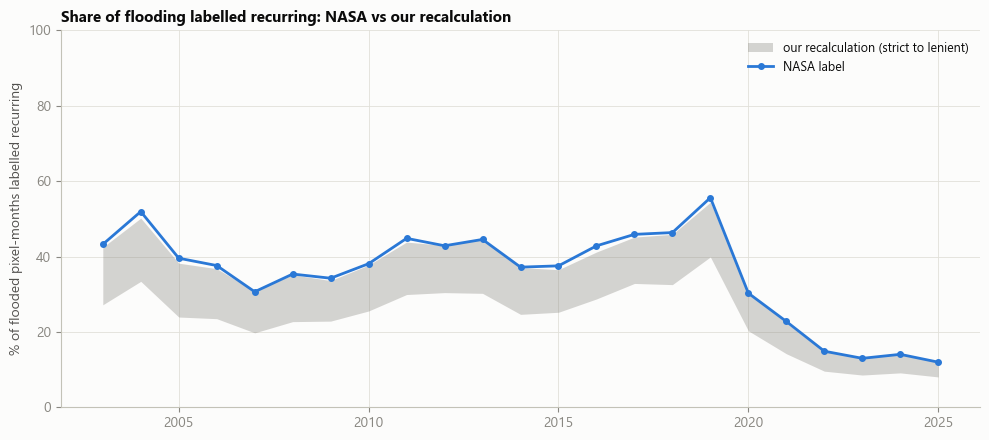

In [10]:
flooded = obs[["pixel", "year", "month"]].drop_duplicates().merge(nasa, on=["pixel", "month"])
share = pd.DataFrame({
    "NASA": flooded.groupby("year")["nasa"].apply(lambda s: (s == "recurring").mean() * 100),
    "ours, strict": flooded.groupby("year")["strict"].mean() * 100,
    "ours, lenient": flooded.groupby("year")["lenient"].mean() * 100,
})
display(share.round(1))

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.fill_between(share.index, share["ours, strict"], share["ours, lenient"], color=MUTED, alpha=0.35, lw=0,
                label="our recalculation (strict to lenient)")
ax.plot(share.index, share["NASA"], color=BLUE, lw=2, marker="o", ms=4, label="NASA label")
ax.set_ylabel("% of flooded pixel-months labelled recurring")
ax.set_ylim(0, 100)
ax.set_title("Share of flooding labelled recurring: NASA vs our recalculation", loc="left")
ax.legend(loc="upper right", fontsize=9)
fig.tight_layout()
fig.savefig(FIG / "flood_types_recalculated.png", dpi=200)
plt.show()

**Where they disagree**, for October (peak flood season), over South Sudan. Only the disagreements that no value of N can explain are drawn.

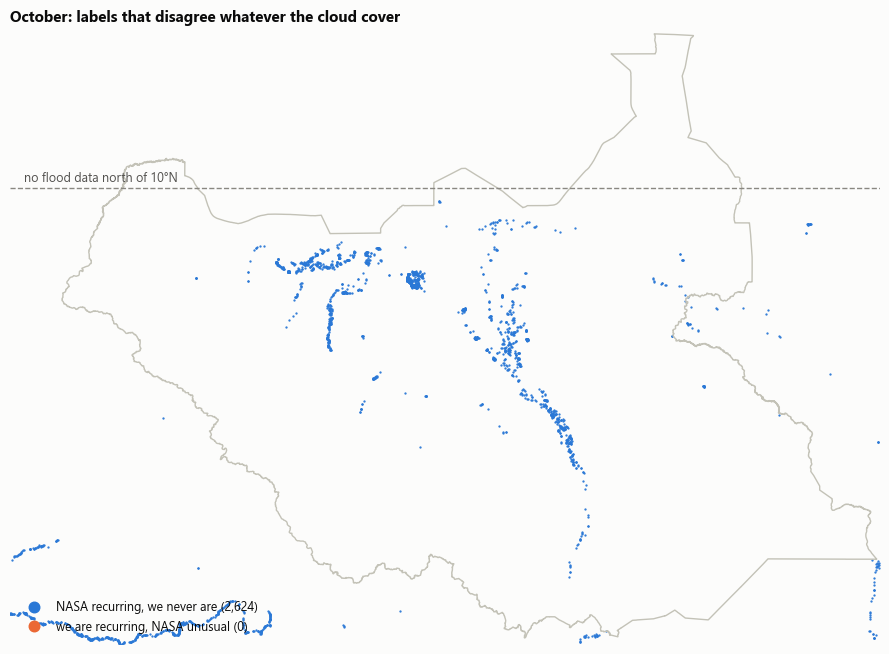

In [11]:
admin0 = gpd.read_file(REPO / "raw_data" / "Administrative boundaries" / "ssd_admin0.geojson")
month = 10
fig, ax = plt.subplots(figsize=(9, 8))
admin0.boundary.plot(ax=ax, color=AXIS, lw=1)
for mask, col, name in [(sure_nasa_only, BLUE, "NASA recurring, we never are"),
                        (sure_ours_only, ORANGE, "we are recurring, NASA unusual")]:
    px = nasa.loc[mask & (nasa["month"] == month), "pixel"].to_numpy()
    lon, lat = (px % 100_000 + 0.5) * RES, (px // 100_000 + 0.5) * RES
    inside = (lon > 23.4) & (lon < 36) & (lat > 3.4)
    ax.scatter(lon[inside], lat[inside], s=0.4, color=col, label=f"{name} ({inside.sum():,})", rasterized=True)
ax.axhline(10, color=MUTED, ls="--", lw=1)
ax.text(23.6, 10.1, "no flood data north of 10°N", fontsize=9, color=INK2)
ax.set_xlim(23.4, 36); ax.set_ylim(3.4, 12.3); ax.set_aspect("equal")
ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
for s in ax.spines.values():
    s.set_visible(False)
ax.legend(loc="lower left", markerscale=12, fontsize=9)
ax.set_title("October: labels that disagree whatever the cloud cover", loc="left")
fig.tight_layout()
fig.savefig(FIG / "flood_types_disagreement_october.png", dpi=200)
plt.show()

#### 5. Variant: the same rule against a pre-2020 reference period
NASA's reference period (2003–2024) includes the wet years after 2020, which mixes the "normal" and the "new" situation. Recompute the rule over **2003–2019** only (17 years, so at least 6 flood years for one in three) and see how much of each year's flooding is *outside* that older normal area.

,NASA,"pre-2020 reference, strict","pre-2020 reference, lenient"
year,,,
2003,56.8,75.9,61.0
2004,48.1,70.1,53.6
2005,60.5,78.4,64.8
2006,62.4,78.7,65.7
2007,69.4,82.1,71.4
2008,64.7,80.0,68.2
2009,65.8,78.5,67.5
2010,61.9,76.2,63.9
2011,55.2,71.6,57.1


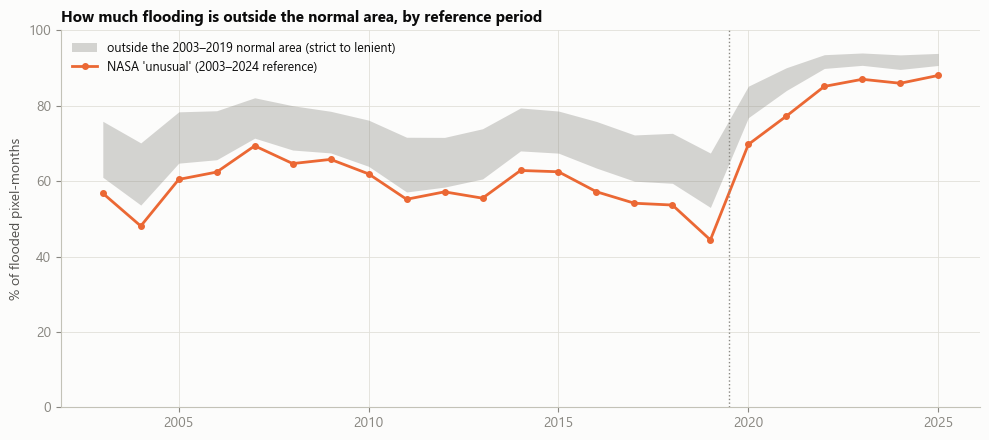

In [12]:
pre = {"strict": recurring_mask(K_STRICT, 2003, 2019, 6), "lenient": recurring_mask(K_LENIENT, 2003, 2019, 6)}
f = obs[["pixel", "year", "month"]].drop_duplicates()
unusual_share = pd.DataFrame({"NASA": 100 - share["NASA"]})
for name, mask in pre.items():
    hit = f.merge(mask.assign(rec=True), on=["pixel", "month"], how="left")["rec"].fillna(False).astype(bool)
    unusual_share[f"pre-2020 reference, {name}"] = 100 - hit.groupby(f["year"].to_numpy()).mean() * 100
display(unusual_share.round(1))

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.fill_between(unusual_share.index, unusual_share["pre-2020 reference, lenient"],
                unusual_share["pre-2020 reference, strict"], color=MUTED, alpha=0.35, lw=0,
                label="outside the 2003–2019 normal area (strict to lenient)")
ax.plot(unusual_share.index, unusual_share["NASA"], color=ORANGE, lw=2, marker="o", ms=4,
        label="NASA 'unusual' (2003–2024 reference)")
ax.axvline(2019.5, color=MUTED, ls=":", lw=1)
ax.set_ylabel("% of flooded pixel-months")
ax.set_ylim(0, 100)
ax.set_title("How much flooding is outside the normal area, by reference period", loc="left")
ax.legend(loc="upper left", fontsize=9)
fig.tight_layout()
fig.savefig(FIG / "flood_types_pre2020_reference.png", dpi=200)
plt.show()

#### 6. Where is the post-2020 unusual flooding?

In [13]:
unusual = obs[obs["label"] == "unusual"]
before = set(unusual.loc[unusual["year"] <= 2019, "pixel"])
after = set(unusual.loc[unusual["year"] >= 2020, "pixel"])
ever_recurring = set(obs.loc[obs["label"] == "recurring", "pixel"])
new = after - before
print(f"pixels with unusual flooding 2020–2025: {len(after):,}")
print(f"  never unusually flooded in 2003–2019:  {len(new):,} ({len(new) / len(after):.0%})")
print(f"  ... and never recurring in any month:  {len(new - ever_recurring):,}")
years_new = unusual[unusual["pixel"].isin(new) & (unusual["year"] >= 2020)].groupby("pixel")["year"].nunique()
display(years_new.value_counts().sort_index().rename_axis("years flooded 2020–2025").rename("pixels").to_frame().T)

pixels with unusual flooding 2020–2025: 1,078,419
  never unusually flooded in 2003–2019:  675,221 (63%)
  ... and never recurring in any month:  670,516


years flooded 2020–2025,1,2,3,4,5,6
pixels,413046,137223,64078,39210,17090,4574


#### What this means for the project

1. **NASA's labels are computed correctly, as far as we can check.** Recalculated with the rule from section 3.5.2, our labels agree with NASA's for 96.7% (strict) to 98.5% (lenient) of pixel-months, and NASA's yearly share of recurring flooding sits right on the lenient edge of our range in every year. That is what you would expect if the flood season is cloudy, so most windows have few clear days (low N). The remaining differences come from what we don't have: the per-pixel cloud information, and NASA's 2-day composites (ours are 3-day).
2. **The label describes the place, not the flood.** Recurring = "inside the area that normally floods in this month"; unusual = "outside it". That's a useful distinction for the dashboard and for anticipatory action: pre-season preparation can target the recurring area, and unusual flooding is what takes people by surprise.
3. **Recurring flooding can't grow, by design.** It's limited to a fixed mask, so all growth after 2020 shows up as unusual: from about 58% of flooded pixel-months being unusual in 2003–2019 to about 87% in 2022–2025, mostly in about 675 thousand pixels that had never flooded before. Use total flooded area for trends; use the split only to say *where* the flooding is.
4. **The choice of reference period matters little.** Against a pre-2020 "normal area", the share of unusual flooding in 2020–2025 is 77–94% (lenient to strict), against NASA's 70–88%. NASA's mask is fine to use as it is; there's no need to build our own.
5. **Data gaps:** April and May 2006 (18 and 19 days without records) and November 2007 (12 days) undercount flooding. They're flagged in `data/interim/flood_months.csv` and should be marked in any monthly time series.